# Confidence intervals — TES (Al), heavy mediator (F_DM = 1), m_DM = 10 MeV

Point-wise profile confidence bands of the recovered flux x(v_min), one
subsection per halo model. Method and conventions:
[`quantum_sensor.statistics.find_confidence_band`](../src/quantum_sensor/statistics.py)
(neutrinoAnalysis construction: observed profile Δχ² vs an MC-calibrated
cutoff; Poisson pseudo-experiments; CLARABEL solver, thread-parallel).

- Configuration: `material='Al', q='0', mass='1', nbins=5`, background `none`
- Outputs per model: `results/TES/bkg-none/<config>/` —
  `band/band_idx*.json` (primary, one per point), `flux_profile_band.csv`
  (summary), `flux_profile_band.pdf` (figure)
- **Each `run_model` cell takes ~30–60 min** (production MC settings).
  Already computed? Use `show_saved` in §Saved results instead.


In [1]:
import numpy as np
import matplotlib.pyplot as plt

from quantum_sensor import (DarkMatterQuantumAnalysis, RunConfig,
                            pointwise_band, load_pointwise_band,
                            band_table, save_band_products)
from quantum_sensor.plotting import plot_flux_with_pointwise_bands, run_dir

MATERIAL, Q, MASS, NBINS = 'Al', '0', '1', 5
LEVELS = (0.68, 0.954)                                   # 1 sigma, 2 sigma
MC = dict(num_pseudo=50, n_pseudo_edge=500, rel_tol=0.02)  # production settings
N_INDICES = 30


def build(eta='Halo', disk_fraction=None):
    cfg = RunConfig(material=MATERIAL, q=Q, mass=MASS, nbins=NBINS,
                    eta=eta, disk_fraction=disk_fraction, background='none')
    a = DarkMatterQuantumAnalysis(cfg)
    a.optimize()
    return a


def run_model(eta='Halo', disk_fraction=None):
    """Compute, save and display the band for one halo model (heavy)."""
    a = build(eta, disk_fraction)
    print(f'{a.config}')
    print(f'counts per bin: {np.array2string(a.observed, precision=1)}')
    bands = pointwise_band(a, n_indices=N_INDICES, levels=LEVELS, **MC)
    save_band_products(a, bands)
    display(band_table(bands))
    return a, bands


def show_saved(eta='Halo', disk_fraction=None):
    """Reload a saved band (band/*.json) — no recomputation."""
    a = build(eta, disk_fraction)
    bands = load_pointwise_band(run_dir(a))
    print(f'{len(bands)} points from {run_dir(a) / "band"}')
    display(band_table(bands))
    plot_flux_with_pointwise_bands(a, bands, save=False)
    return a, bands


## 1. Standard halo (SHM)


RunConfig(material='Al', q='0', mass='1', nbins=5, eta='Halo', disk_fraction=None, background='none', run=None)
counts per bin: [1638.3 3228.5 4712.5 6136.9 7464.5]
[1/24] idx 0 (v=43 km/s)  best 4.01e-26 cm^-1  1sigma [3.84e-26, 4.35e-23]  2sigma [3.74e-26, 8.44e-23]  (42 evals)
[2/24] idx 1 (v=44 km/s)  best 4.01e-26 cm^-1  1sigma [3.79e-26, 1.64e-23]  2sigma [3.7e-26, 3.3e-23]  (40 evals)
[3/24] idx 2 (v=45 km/s)  best 4.01e-26 cm^-1  1sigma [3.79e-26, 7.17e-24]  2sigma [3.7e-26, 1.46e-23]  (38 evals)
[4/24] idx 3 (v=45 km/s)  best 4.01e-26 cm^-1  1sigma [3.79e-26, 4.28e-24]  2sigma [3.7e-26, 7.77e-24]  (35 evals)
[5/24] idx 4 (v=46 km/s)  best 4.01e-26 cm^-1  1sigma [3.79e-26, 3.04e-24]  2sigma [3.7e-26, 5.88e-24]  (36 evals)
[6/24] idx 5 (v=47 km/s)  best 4.01e-26 cm^-1  1sigma [3.79e-26, 1.94e-24]  2sigma [3.7e-26, 3.44e-24]  (32 evals)
[7/24] idx 6 (v=48 km/s)  best 4.01e-26 cm^-1  1sigma [3.79e-26, 1.39e-24]  2sigma [3.7e-26, 2.6e-24]  (32 evals)
[8/24] idx 8 (v=49 km/s)  best 

,index,vmin [km/s],best fit [cm^-1],lo 1sigma [cm^-1],hi 1sigma [cm^-1],lo 2sigma [cm^-1],hi 2sigma [cm^-1],-68%,+68%,evals
0,0,42.9,4.012241e-26,3.838272e-26,4.352492e-23,3.742226e-26,8.438437e-23,-4%,+108380%,42
1,1,43.7,4.012241e-26,3.789945e-26,1.636757e-23,3.695108e-26,3.296224e-23,-6%,+40694%,40
2,2,44.5,4.012241e-26,3.789945e-26,7.165802e-24,3.695108e-26,1.461505e-23,-6%,+17760%,38
3,3,45.3,4.012241e-26,3.789945e-26,4.275843e-24,3.695108e-26,7.768615e-24,-6%,+10557%,35
4,4,46.1,4.012241e-26,3.789945e-26,3.044223e-24,3.695108e-26,5.883351e-24,-6%,+7487%,36
5,5,46.9,4.012241e-26,3.789945e-26,1.936120e-24,3.695108e-26,3.440520e-24,-6%,+4726%,32
6,6,47.7,4.012241e-26,3.789945e-26,1.390498e-24,3.695108e-26,2.603523e-24,-6%,+3366%,32
7,8,49.3,4.012241e-26,3.789945e-26,8.179615e-25,3.695108e-26,1.531525e-24,-6%,+1939%,30
8,9,50.1,4.012241e-26,3.789945e-26,6.796004e-25,3.695108e-26,1.219194e-24,-6%,+1594%,30
9,11,51.7,4.012241e-26,3.789945e-26,4.427781e-25,3.695108e-26,8.238078e-25,-6%,+1004%,26


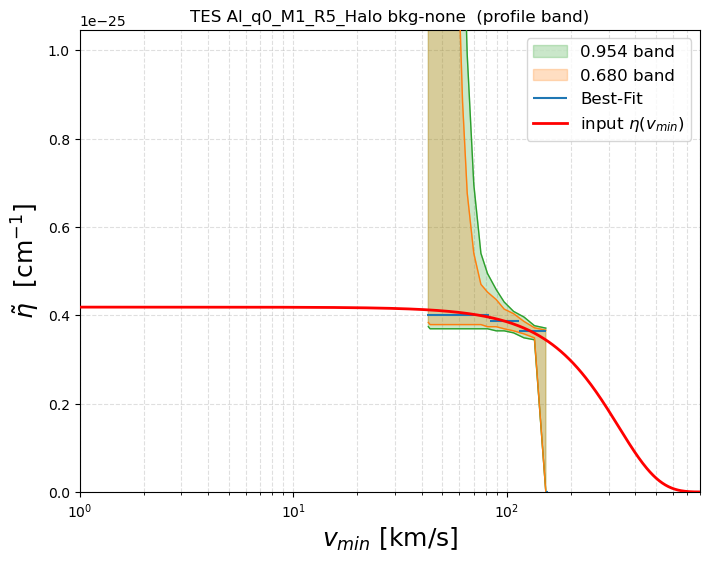

In [2]:
a_halo, b_halo = run_model(eta='Halo')


## 2. Pure dark disk


In [ ]:
a_disk, b_disk = run_model(eta='Disk')


## 3. Halo + dark-disk mixtures

The fit eta is `(1-p)·Halo + p·Disk` with the same total local DM density.


RunConfig(material='Al', q='0', mass='1', nbins=5, eta='Halo', disk_fraction=0.05, background='none', run=None)
counts per bin: [1699.9 3308.1 4763.8 6122.2 7359.5]
[1/24] idx 0 (v=43 km/s)  best 4.23e-26 cm^-1  1sigma [3.94e-26, 5.02e-23]  2sigma [3.89e-26, 9.3e-23]  (41 evals)
[2/24] idx 1 (v=44 km/s)  best 4.23e-26 cm^-1  1sigma [3.89e-26, 2.03e-23]  2sigma [3.8e-26, 3.97e-23]  (41 evals)
[3/24] idx 2 (v=45 km/s)  best 4.23e-26 cm^-1  1sigma [3.89e-26, 8.71e-24]  2sigma [3.8e-26, 1.6e-23]  (39 evals)
[4/24] idx 3 (v=45 km/s)  best 4.23e-26 cm^-1  1sigma [3.89e-26, 5.23e-24]  2sigma [3.8e-26, 9.2e-24]  (38 evals)
[5/24] idx 4 (v=46 km/s)  best 4.23e-26 cm^-1  1sigma [3.89e-26, 3.56e-24]  2sigma [3.8e-26, 6.39e-24]  (38 evals)
[6/24] idx 5 (v=47 km/s)  best 4.23e-26 cm^-1  1sigma [3.89e-26, 2.4e-24]  2sigma [3.8e-26, 4.33e-24]  (33 evals)
[7/24] idx 6 (v=48 km/s)  best 4.23e-26 cm^-1  1sigma [3.89e-26, 1.57e-24]  2sigma [3.8e-26, 3.27e-24]  (34 evals)
[8/24] idx 8 (v=49 km/s)  best 4.

,index,vmin [km/s],best fit [cm^-1],lo 1sigma [cm^-1],hi 1sigma [cm^-1],lo 2sigma [cm^-1],hi 2sigma [cm^-1],-68%,+68%,evals
0,0,42.9,4.227697e-26,3.943182e-26,5.019525e-23,3.893534e-26,9.302137e-23,-7%,+118630%,41
1,1,43.7,4.227697e-26,3.893534e-26,2.027040e-23,3.796106e-26,3.973757e-23,-8%,+47847%,41
2,2,44.5,4.227697e-26,3.893534e-26,8.707405e-24,3.796106e-26,1.595857e-23,-8%,+20496%,39
3,3,45.3,4.227697e-26,3.893534e-26,5.226681e-24,3.796106e-26,9.200062e-24,-8%,+12263%,38
4,4,46.1,4.227697e-26,3.893534e-26,3.555527e-24,3.796106e-26,6.393738e-24,-8%,+8310%,38
5,5,46.9,4.227697e-26,3.893534e-26,2.399703e-24,3.796106e-26,4.325538e-24,-8%,+5576%,33
6,6,47.7,4.227697e-26,3.893534e-26,1.570915e-24,3.796106e-26,3.265445e-24,-8%,+3616%,34
7,8,49.3,4.227697e-26,3.893534e-26,1.012208e-24,3.796106e-26,1.907271e-24,-8%,+2294%,32
8,9,50.1,4.227697e-26,3.893534e-26,7.800361e-25,3.796106e-26,1.399374e-24,-8%,+1745%,32
9,11,51.7,4.227697e-26,3.893534e-26,4.785295e-25,3.796106e-26,9.248195e-25,-8%,+1032%,28


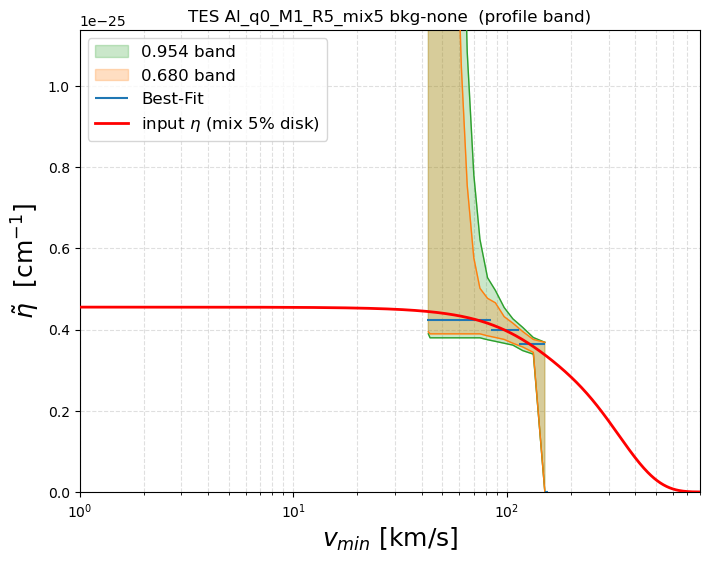

In [3]:
a_mix5, b_mix5 = run_model(disk_fraction=0.05)    # 5% disk


In [ ]:
a_mix25, b_mix25 = run_model(disk_fraction=0.25)  # 25% disk


## Saved results (no recomputation)

Reload any model computed above (or in a previous session).


28 points from /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/TES/bkg-none/Al_q0_M1_R5_Halo/band


,index,vmin [km/s],best fit [cm^-1],lo 1sigma [cm^-1],hi 1sigma [cm^-1],lo 2sigma [cm^-1],hi 2sigma [cm^-1],-68%,+68%,evals
0,0,42.9,4.012241e-26,3.838272e-26,4.352492e-23,3.742226e-26,8.438437e-23,-4%,+108380%,42
1,1,43.7,4.012241e-26,3.789945e-26,1.636757e-23,3.695108e-26,3.296224e-23,-6%,+40694%,40
2,2,44.5,4.012241e-26,3.789945e-26,7.165802e-24,3.695108e-26,1.461505e-23,-6%,+17760%,38
3,3,45.3,4.012241e-26,3.789945e-26,4.275843e-24,3.695108e-26,7.768615e-24,-6%,+10557%,35
4,4,46.1,4.012241e-26,3.789945e-26,3.044223e-24,3.695108e-26,5.883351e-24,-6%,+7487%,36
5,5,46.9,4.012241e-26,3.789945e-26,1.936120e-24,3.695108e-26,3.440520e-24,-6%,+4726%,32
6,6,47.7,4.012241e-26,3.789945e-26,1.390498e-24,3.695108e-26,2.603523e-24,-6%,+3366%,32
7,8,49.3,4.012241e-26,3.789945e-26,8.179615e-25,3.695108e-26,1.531525e-24,-6%,+1939%,30
8,9,50.1,4.012241e-26,3.789945e-26,6.796004e-25,3.695108e-26,1.219194e-24,-6%,+1594%,30
9,11,51.7,4.012241e-26,3.789945e-26,4.427781e-25,3.695108e-26,8.238078e-25,-6%,+1004%,26


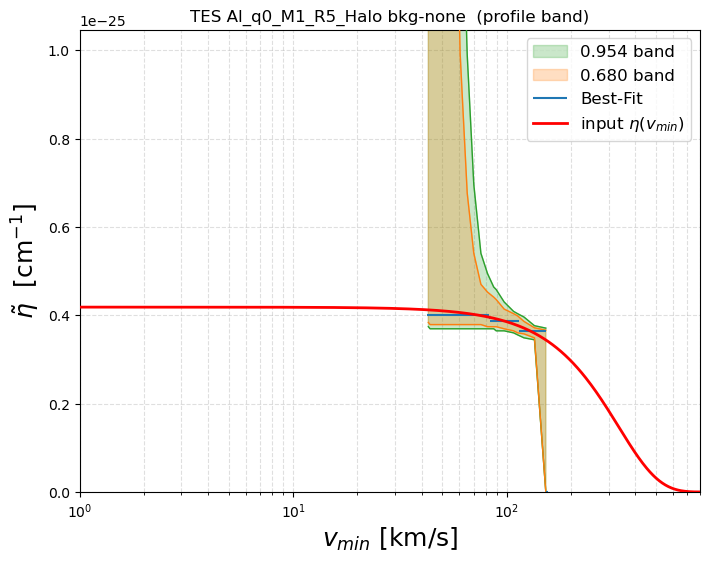

In [4]:
show_saved(eta='Halo');
# show_saved(eta='Disk');
# show_saved(disk_fraction=0.05);
# show_saved(disk_fraction=0.25);
